<a href="https://colab.research.google.com/github/Mehtab23455/Rainfall-Predictor-using-Random-Forest-Classifier/blob/main/Rainfall_Prediction_using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing the dependencies**

In [83]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pickle

**Data Collection and Processing**

In [ ]:
# laod the dataset to a pandas dataframe
data = pd.read_csv("/content/drive/MyDrive/Rainfall.csv")

In [ ]:
print(type(data))

In [ ]:
data.shape

In [ ]:
data.head()

In [ ]:
data.tail()

In [ ]:
data["day"].unique()

In [ ]:
print("Data Info:")
data.info()

In [ ]:
data.columns

In [ ]:
# remove extra  spaces in all columns
data.columns = data.columns.str.strip()

In [ ]:
data.columns

In [ ]:
print("Data Info:")
data.info()

In [ ]:
data = data.drop(columns=["day"])

In [ ]:
data.head()

In [ ]:
# checking the number of missing values
print(data.isnull().sum())

In [ ]:
data["winddirection"].unique()

In [ ]:
# handle missing values
data["winddirection"] = data["winddirection"].fillna(data["winddirection"].mode()[0])
data["windspeed"] = data["windspeed"].fillna(data["windspeed"].median())

In [ ]:
# checking the number of missing values
print(data.isnull().sum())

In [ ]:
data["rainfall"].unique()

In [ ]:
# converting the yes & no to 1 and 0 respectively
data["rainfall"] = data["rainfall"].map({"yes": 1, "no": 0})

In [ ]:
data.head()

**Exploratory Data Analysis (EDA)**

In [ ]:
data.shape

In [ ]:
# setting plot style for all the plots
sns.set(style="whitegrid")

In [ ]:
data.describe()

In [ ]:
data.columns

In [ ]:
plt.figure(figsize=(15, 10))

for i, column in enumerate(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity','cloud', 'sunshine', 'windspeed'], 1):
  plt.subplot(3, 3, i)
  sns.histplot(data[column], kde=True)
  plt.title(f"Distribution of {column}")

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x="rainfall", data=data)
plt.title("Distribution of Rainfall")
plt.show()

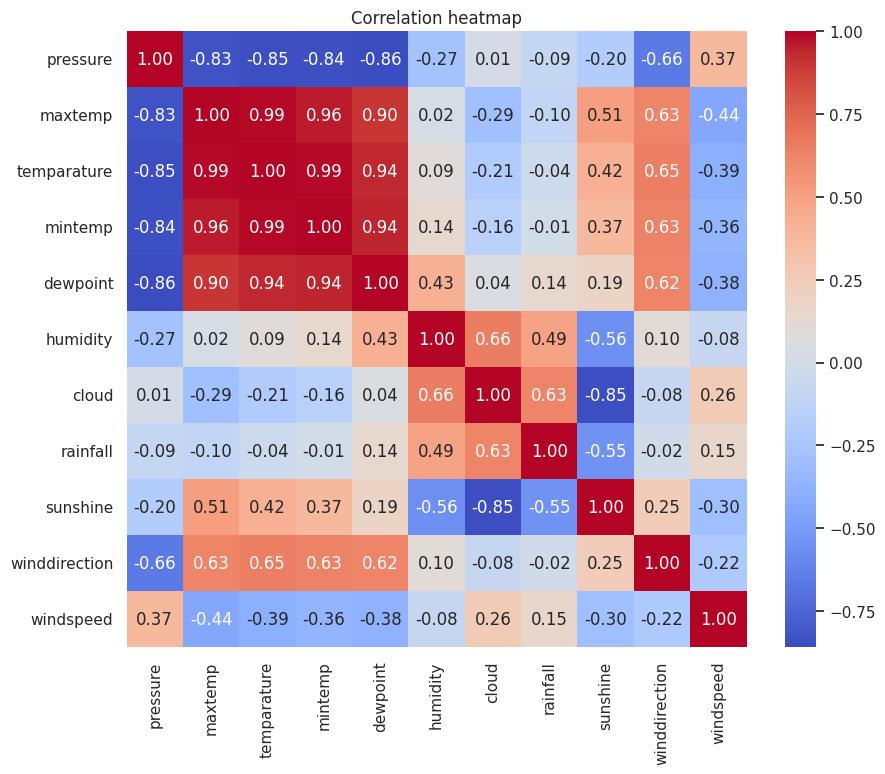

In [111]:
# correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap")
plt.show()

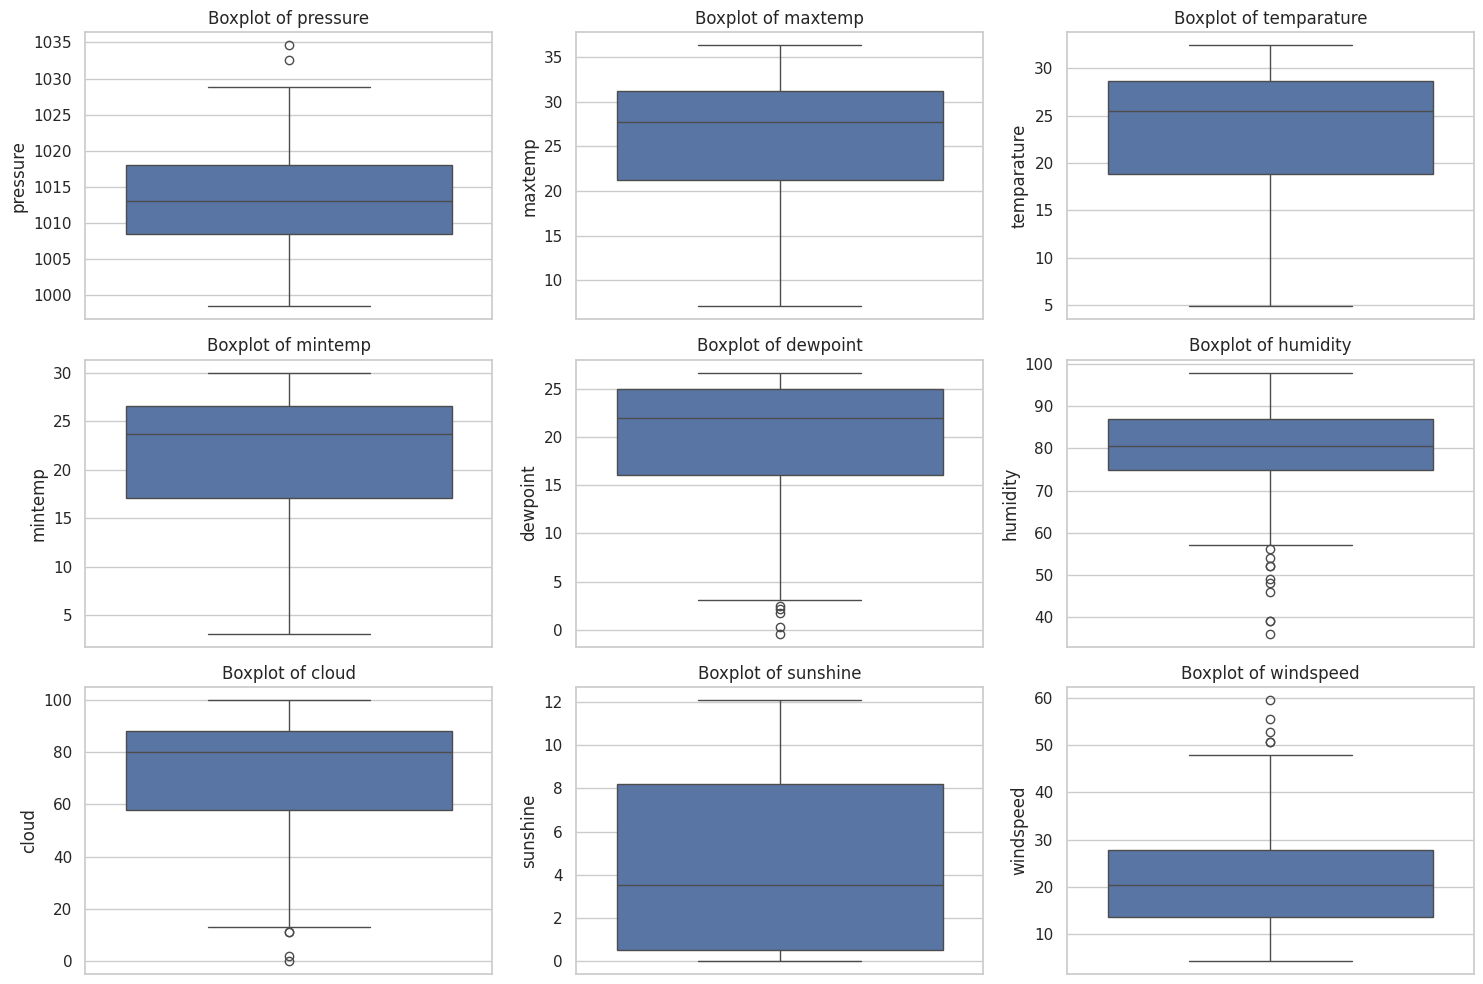

In [112]:
plt.figure(figsize=(15, 10))

for i, column in enumerate(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity','cloud', 'sunshine', 'windspeed'], 1):
  plt.subplot(3, 3, i)
  sns.boxplot(data[column])
  plt.title(f"Boxplot of {column}")

plt.tight_layout()
plt.show()

**Data Preprocessing**

In [113]:
# drop highly correlated column
data = data.drop(columns=['maxtemp', 'temparature', 'mintemp'])

In [114]:
data.head()

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,13.1,72,49,1,9.3,80.0,26.3
1,1022.0,15.6,81,83,1,0.6,50.0,15.3
2,1019.7,18.4,95,91,1,0.0,40.0,14.2
3,1018.9,18.8,90,88,1,1.0,50.0,16.9
4,1015.9,19.9,95,81,1,0.0,40.0,13.7


In [115]:
print(data["rainfall"].value_counts())

rainfall
1    249
0    117
Name: count, dtype: int64


In [116]:
# separate majority and minority class
df_majority = data[data["rainfall"] == 1]
df_minority = data[data["rainfall"] == 0]

In [117]:
print(df_majority.shape)
print(df_minority.shape)

(249, 8)
(117, 8)


In [118]:
# downsample majority class to match minority count
df_majority_downsampled = resample(df_majority, replace=False, n_samples=len(df_minority), random_state=42)

In [119]:
df_majority_downsampled.shape

(117, 8)

In [120]:
df_downsampled = pd.concat([df_majority_downsampled, df_minority])

In [121]:
df_downsampled.shape

(234, 8)

In [122]:
df_downsampled.head()

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
188,1005.9,25.6,77,53,1,10.5,270.0,11.3
9,1017.5,15.5,85,91,1,0.0,70.0,37.7
137,1012.3,20.1,80,86,1,0.3,80.0,39.5
89,1018.3,16.3,79,89,1,2.4,40.0,14.8
157,1008.8,24.7,91,80,1,2.2,20.0,11.2


In [123]:
# shuffle the final dataframe
df_downsampled = df_downsampled.sample(frac=1, random_state=42).reset_index(drop=True)

In [124]:
df_downsampled.head()

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1022.2,14.1,78,90,1,0.0,30.0,28.5
1,1013.4,19.5,69,17,0,10.5,70.0,12.4
2,1006.1,24.4,74,27,0,10.8,220.0,8.7
3,1007.6,24.8,85,84,1,1.8,70.0,34.8
4,1021.2,8.4,66,18,0,10.1,20.0,24.4


In [125]:
df_downsampled["rainfall"].value_counts()

,count
rainfall,
1,117
0,117


In [126]:
# split features and target as X and y
X = df_downsampled.drop(columns=["rainfall"])
y = df_downsampled["rainfall"]

In [127]:
print(X)

     pressure  dewpoint  humidity  cloud  sunshine  winddirection  windspeed
0      1022.2      14.1        78     90       0.0           30.0       28.5
1      1013.4      19.5        69     17      10.5           70.0       12.4
2      1006.1      24.4        74     27      10.8          220.0        8.7
3      1007.6      24.8        85     84       1.8           70.0       34.8
4      1021.2       8.4        66     18      10.1           20.0       24.4
..        ...       ...       ...    ...       ...            ...        ...
229    1008.1      25.4        86     75       5.7           20.0        9.5
230    1010.1      19.9        91     89       0.0           70.0       31.8
231    1020.6      14.7        91     88       0.3           50.0       24.4
232    1008.3      24.1        74     29       5.7           10.0        4.4
233    1005.0      26.1        87     82       2.2          160.0       12.6

[234 rows x 7 columns]


In [128]:
print(y)

0      1
1      0
2      0
3      1
4      0
      ..
229    1
230    1
231    1
232    0
233    1
Name: rainfall, Length: 234, dtype: int64


In [129]:
# splitting the data into training data and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Model Training**

In [130]:
rf_model = RandomForestClassifier(random_state=42)

param_grid_rf = {
    "n_estimators": [50, 100, 200],
    "max_features": ["sqrt", "log2"],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [58]:
# Hypertuning using GridSearchCV
grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid_rf, cv=5, n_jobs=-1, verbose=2)

grid_search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             verbose=2)

In [59]:
best_rf_model = grid_search_rf.best_estimator_

print("best parameters for Random Forest:", grid_search_rf.best_params_)

best parameters for Random Forest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}


**Model Evaluation**

In [60]:
cv_scores = cross_val_score(best_rf_model, X_train, y_train, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean cross-validation score:", np.mean(cv_scores))

Cross-validation scores: [0.68421053 0.81578947 0.83783784 0.83783784 0.91891892]
Mean cross-validation score: 0.818918918918919


In [61]:
# test set performance
y_pred = best_rf_model.predict(X_test)

print("Test set Accuracy:", accuracy_score(y_test, y_pred))
print("Test set Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Test set Accuracy: 0.7446808510638298
Test set Confusion Matrix:
 [[17  7]
 [ 5 18]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.71      0.74        24
           1       0.72      0.78      0.75        23

    accuracy                           0.74        47
   macro avg       0.75      0.75      0.74        47
weighted avg       0.75      0.74      0.74        47



**Prediction on unknown data**

In [62]:
input_data = (1015.9, 19.9, 95, 81, 0.0, 40.0, 13.7)

input_df = pd.DataFrame([input_data], columns=['pressure', 'dewpoint', 'humidity', 'cloud', 'sunshine','winddirection', 'windspeed'])

In [63]:
input_df

,pressure,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,1015.9,19.9,95,81,0.0,40.0,13.7


In [64]:
prediction = best_rf_model.predict(input_df)

In [65]:
print(prediction)

[1]


In [66]:
prediction[0]

np.int64(1)

In [67]:
prediction = best_rf_model.predict(input_df)
print("Prediction result:", "Rainfall" if prediction[0] == 1 else "No Rainfall")

Prediction result: Rainfall


In [68]:
# save model and feature names to a pickle file
model_data = {"model": best_rf_model, "feature_names": X.columns.tolist()}

with open("rainfall_prediction_model.pkl", "wb") as file:
  pickle.dump(model_data, file)

**Load the saved model and file and use it for prediction**

In [69]:
import pickle
import pandas as pd

In [70]:
# load the trained model and feature names from the pickle file
with open("rainfall_prediction_model.pkl", "rb") as file:
  model_data = pickle.load(file)

In [71]:
model = model_data["model"]
feature_names = model_data["feature_names"]

In [72]:
input_data = (1015.9, 19.9, 95, 81, 0.0, 40.0, 13.7)

input_df = pd.DataFrame([input_data], columns=feature_names)

In [73]:
prediction = best_rf_model.predict(input_df)
print("Prediction result:", "Rainfall" if prediction[0] == 1 else "No Rainfall")

Prediction result: Rainfall


**To Try:**
1. SMOTE for class balancing
2. PCA for dimensionality reduction
3. Simpler models like Logistic Regression (with Feature scaling)
4. Model Selection with hyperparameter tuning

In [74]:
model_data = {"model": best_rf_model, "feature_names": X.columns.tolist()}

with open("rainfall_prediction_model.pkl", "wb") as file:
  pickle.dump(model_data, file)

In [75]:
import pickle
import pandas as pd

In [76]:
with open("rainfall_prediction_model.pkl", "rb") as file:
  model_data = pickle.load(file)

In [77]:
model = model_data["model"]
feature_names = model_data["feature_names"]

In [78]:
input_data = (1015.9, 19.9, 95, 81, 0.0, 40.0, 13.7)

input_df = pd.DataFrame([input_data], columns=feature_names)

In [79]:
prediction = best_rf_model.predict(input_df)
print("Prediction result:", "Rainfall" if prediction[0] == 1 else "No Rainfall")

Prediction result: Rainfall


In [80]:
!git clone https://github.com/Mehtab23455/https://github.com/Mehtab23455/Rainfall-Predictor-using-Random-Forest-Classifier
%cd https://github.com/Mehtab23455/Rainfall-Predictor-using-Random-Forest-Classifier
!git checkout -b main

Cloning into 'Rainfall-Predictor-using-Random-Forest-Classifier'...
remote: Not Found
fatal: repository 'https://github.com/Mehtab23455/https://github.com/Mehtab23455/Rainfall-Predictor-using-Random-Forest-Classifier/' not found
[Errno 2] No such file or directory: 'https://github.com/Mehtab23455/Rainfall-Predictor-using-Random-Forest-Classifier'
/content
fatal: not a git repository (or any of the parent directories): .git


In [81]:
!cp /content/Rainfall_Prediction_using_Machine_Learning.ipynb /content/https://github.com/Mehtab23455/Rainfall-Predictor-using-Random-Forest-Classifier/


cp: cannot stat '/content/Rainfall_Prediction_using_Machine_Learning.ipynb': No such file or directory


In [82]:
!git add .
!git commit -m "Add Rain Wizard project"
!git push origin main

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


In [131]:
!git checkout -b rainfall-predictor

fatal: not a git repository (or any of the parent directories): .git


In [132]:
!cp /content/Rainfall_Prediction_using_Machine_Learning.ipynb /content/https://github.com/Mehtab23455/Rainfall-Predictor-using-Random-Forest-Classifier/

cp: cannot stat '/content/Rainfall_Prediction_using_Machine_Learning.ipynb': No such file or directory


In [133]:
!git add .
!git commit -m "Add initial rainfall predictor project"
!git push origin rainfall-predictor

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


In [134]:
!git clone https://github.com/Mehtab23455/https://github.com/Mehtab23455/Rainfall-Predictor-using-Random-Forest-Classifier.git

Cloning into 'Rainfall-Predictor-using-Random-Forest-Classifier'...
remote: Not Found
fatal: repository 'https://github.com/Mehtab23455/https://github.com/Mehtab23455/Rainfall-Predictor-using-Random-Forest-Classifier.git/' not found


In [135]:
%cd https://github.com/Mehtab23455/Rainfall-Predictor-using-Random-Forest-Classifier

[Errno 2] No such file or directory: 'https://github.com/Mehtab23455/Rainfall-Predictor-using-Random-Forest-Classifier'
/content


In [136]:
!git clone https://github.com/Mehtab23455/Rainfall-Predictor-using-Random-Forest-Classifier.git
%cd Rainfall-Predictor-using-Random-Forest-Classifier


Cloning into 'Rainfall-Predictor-using-Random-Forest-Classifier'...
/content/Rainfall-Predictor-using-Random-Forest-Classifier


In [137]:
!git checkout -b rainfall-ml-colab


Switched to a new branch 'rainfall-ml-colab'


In [138]:
!cp /content/Rainfall_Prediction_using_Machine_Learning.ipynb /content/Rainfall-Predictor-using-Random-Forest-Classifier/
%cd /content/Rainfall-Predictor-using-Random-Forest-Classifier


cp: cannot stat '/content/Rainfall_Prediction_using_Machine_Learning.ipynb': No such file or directory
/content/Rainfall-Predictor-using-Random-Forest-Classifier


In [140]:
!git config --global user.name "Mehtab23455"
!git config --global user.email "sidhumehtab465@gmail.com"


In [141]:
!git add .
!git commit -m "Add rainfall predictor project from Colab"
!git push origin rainfall-ml-colab

On branch rainfall-ml-colab

Initial commit

nothing to commit (create/copy files and use "git add" to track)
error: src refspec rainfall-ml-colab does not match any
error: failed to push some refs to 'https://github.com/Mehtab23455/Rainfall-Predictor-using-Random-Forest-Classifier.git'


In [142]:
!ls /content


drive
rainfall_prediction_model.pkl
Rainfall-Predictor-using-Random-Forest-Classifier
sample_data


In [143]:
!cp /content/drive/MyDrive/Rainfall_Prediction_ML.ipynb /content/Rainfall-Predictor-using-Random-Forest-Classifier/


cp: cannot stat '/content/drive/MyDrive/Rainfall_Prediction_ML.ipynb': No such file or directory


In [144]:
!ls /content/drive/MyDrive


'archive (19)'
 CarPrice_Assignment.csv
'Colab Notebooks'
 delhi-data.csv
 mlo
 netflix_titles.csv
'Outlier Detection Removal using Z-Score Method.pdf'
 placement.csv
 Rainfall.csv
 RS_Session_262_AU_2113_1.csv
 Social_Network_Ads.csv
 STATE_AND_TYPEWISE_UNIVERSITIES.csv
 student_pass_fail_final.csv
'Student Success Prediction using Logistic Regression.pptx'
 tmdb_5000_credits.csv
 tmdb_5000_movies.csv
''$'\n''.txt'


In [145]:
!ls /content/drive/MyDrive


'archive (19)'
 CarPrice_Assignment.csv
'Colab Notebooks'
 delhi-data.csv
 mlo
 netflix_titles.csv
'Outlier Detection Removal using Z-Score Method.pdf'
 placement.csv
 Rainfall.csv
 RS_Session_262_AU_2113_1.csv
 Social_Network_Ads.csv
 STATE_AND_TYPEWISE_UNIVERSITIES.csv
 student_pass_fail_final.csv
'Student Success Prediction using Logistic Regression.pptx'
 tmdb_5000_credits.csv
 tmdb_5000_movies.csv
''$'\n''.txt'
